1- Chargement des librairies, importation et préparation des données de prêts 

1.1  Lancer Spark sur votre machine, via pySpark sous Python . Quelle version de Spark est installée sur votre machine ? 

In [12]:
#pip install pyspark

In [1]:
import pyspark
spark = pyspark.sql.SparkSession\
.builder\
.appName('test')\
.master("
.local[*]")\
.config()\
.enableHiveSupport()\
.getOrCreate()

SyntaxError: unterminated string literal (detected at line 5) (1432860738.py, line 5)

In [2]:
print("Version Spark  installé :", spark.version,"\n") 
print(sc.version)
print(sc.appName)
print(sc._conf.toDebugString())

NameError: name 'spark' is not defined

1.2 - Importer les 2 fichiers CSV « prets_preteurs.csv » et « prets.csv » dans 2 DataFrames Spark, nommés 'prets_preteurs' et 'prets' respectivement. 

In [2]:
# Dossier où se trouve les fichiers
dossier = "F:/UT1_CAPITOLE/ANNEE 2/UE10 BIG DATA/projet de fin de cours/Donnees_projet/" # destop
#dossier = "F:/UT1_CAPITOLE/ANNEE 2/UE10 BIG DATA/projet de fin de cours/Donnees_projet/" 


# fichiers 
fichierpp = dossier + "prets_preteurs.csv"
fichierp = dossier + "prets.csv"

# Importation du fichier csv
prets_preteurs = spark.read.csv(fichierpp,header=True, inferSchema=True)
prets = spark.read.csv(fichierp,header=True, inferSchema=True) # , na.strings="NA"

1.3 - Combien de lignes et variables ont chaque DataFrame ?
Quels sont les schémas des 2 DataFrames ainsi crées (types de variables - entier, caractères) ? 

In [3]:
# Nombre de lignes et variables de chaque DataFrame
print(" ************************************************************************")
# DataFrame prets_preteurs
nr_pp = prets_preteurs.count() # 1 387 432 lignes
nc_pp = len(prets_preteurs.columns) # 2 variables

print(" Le dataFrame 'prets_preteurs' a :",nc_pp," Variables et ",nr_pp,"lignes")
print(" ************************************************************************")


# DataFrame prets
nr_p = prets.count() # 1 419 607
nc_p = len(prets.columns) # 34 variables
print(" Le 'dataFrame 'prets' a :",nc_p," Variables et ",nr_p,"lignes")
print(" ************************************************************************")

 ************************************************************************
 Le dataFrame 'prets_preteurs' a : 2  Variables et  1387432 lignes
 ************************************************************************
 Le 'dataFrame 'prets' a : 34  Variables et  1419607 lignes
 ************************************************************************


In [4]:
print("**** Schema du dataFrame 'prets_preteurs' ****")
prets_preteurs.printSchema()

**** Schema du dataFrame 'prets_preteurs' ****
root
 |-- LOAN_ID: integer (nullable = true)
 |-- LENDERS: string (nullable = true)



In [5]:
print("**** Schema du dataFrame 'prets' ****")
prets.printSchema()

**** Schema du dataFrame 'prets' ****
root
 |-- LOAN_ID: integer (nullable = true)
 |-- LOAN_NAME: string (nullable = true)
 |-- ORIGINAL_LANGUAGE: string (nullable = true)
 |-- DESCRIPTION: string (nullable = true)
 |-- DESCRIPTION_TRANSLATED: string (nullable = true)
 |-- FUNDED_AMOUNT: string (nullable = true)
 |-- LOAN_AMOUNT: string (nullable = true)
 |-- STATUS: string (nullable = true)
 |-- IMAGE_ID: string (nullable = true)
 |-- VIDEO_ID: string (nullable = true)
 |-- ACTIVITY_NAME: string (nullable = true)
 |-- SECTOR_NAME: string (nullable = true)
 |-- LOAN_USE: string (nullable = true)
 |-- COUNTRY_CODE: string (nullable = true)
 |-- COUNTRY_NAME: string (nullable = true)
 |-- TOWN_NAME: string (nullable = true)
 |-- CURRENCY_POLICY: string (nullable = true)
 |-- CURRENCY_EXCHANGE_COVERAGE_RATE: string (nullable = true)
 |-- CURRENCY: string (nullable = true)
 |-- PARTNER_ID: string (nullable = true)
 |-- POSTED_TIME: string (nullable = true)
 |-- PLANNED_EXPIRATION_TIME: st

1.4 - Ne conserver dans le DataFrame ‘prets’ que les colonnes "LOAN_ID", "LOAN_AMOUNT", "STATUS", "SECTOR_NAME", "COUNTRY_CODE",  "LENDER_TERM", "NUM_LENDERS_TOTAL", "BORROWER_GENDERS", "DISTRIBUTION_MODEL". 


In [12]:
prets = prets.select('LOAN_ID', 'LOAN_AMOUNT', 'STATUS', 'SECTOR_NAME', 'COUNTRY_CODE',  'LENDER_TERM', 'NUM_LENDERS_TOTAL', 'BORROWER_GENDERS', 'DISTRIBUTION_MODEL')
prets.columns # Colonnes conservées

['LOAN_ID',
 'LOAN_AMOUNT',
 'STATUS',
 'SECTOR_NAME',
 'COUNTRY_CODE',
 'LENDER_TERM',
 'NUM_LENDERS_TOTAL',
 'BORROWER_GENDERS',
 'DISTRIBUTION_MODEL']

1.5 - Enlever les doublons et les valeurs manquantes du DataFrame 'prets'. Combien reste-t-il de lignes dans ce DataFrame ? 

In [6]:
# Il sera question d'enlever les valeurs manquantes dans les variables importantes
variables_imp = ["LOAN_AMOUNT","STATUS","SECTOR_NAME","COUNTRY_CODE","LENDER_TERM","NUM_LENDERS_TOTAL","BORROWER_GENDERS","DISTRIBUTION_MODEL"]
prets = prets.dropDuplicates() # Suppression des doublons dans la base
prets = prets.dropna('any',subset=variables_imp) # suppression des données manquantes 
nb = prets.count()
print(" il reste : ", nb ,"lignes dans le data frame après retraits des doublons et données manquantes.")
# Nous notons qu'il s'agit ici des doonnées manqauaantes dans les variables importantes prédfinis. 

 il reste :  1311449 lignes dans le data frame après retraits des doublons et données manquantes.


1.6 - Enlever les prêts dont le nom du pays ('COUNTRY_NAME') n'est pas renseigné (i.e. est 'None' sous Python par exemple), ainsi que les prêts dont le genre des emprunteurs ('BORROWER_GENDERS') ne sont ni masculin ('male') ni féminin ('female') (cela revient à ne garder que les prêts n'ayant qu'un unique emprunteur). Combien de lignes reste-t-il au 
DataFrame 'prets' ?

In [7]:
# retrait des prêts dont le nom du pays ('COUNTRY_NAME') n'est pas renseigné
prets = prets.filter(prets.COUNTRY_NAME != 'None')

# retrait des prêts dont le genre des emprunteurs ('BORROWER_GENDERS') ne sont ni masculin ('male') ni féminin ('female')
prets = prets.filter((prets.BORROWER_GENDERS == "male") | (prets.BORROWER_GENDERS == "female"))

nb = prets.count()
print(" Il reste : ", nb ,"lignes dans le data frame après la question 1.5.")

 Il reste :  1132210 lignes dans le data frame après la question 1.5.


# 2 – Analyse exploratoire des données de prêts  

2.1 – Quelles sont les 5 monnaies (‘CURRENCY’) les plus représentées parmi les prêts ?  
Indication: utiliser les fonctions "groupBy" et "orderBy" sur la variable de 'count' créée et classée dans l'ordre descendant

In [8]:
from pyspark.sql.functions import *
prets.groupBy('CURRENCY').count().select('CURRENCY','count').orderBy("count",ascending = 0).show(5)

+--------+------+
|CURRENCY| count|
+--------+------+
|     PHP|274531|
|     USD|213348|
|     KES|118081|
|     PEN| 59515|
|     PKR| 37177|
+--------+------+
only showing top 5 rows



2.2 – Afin de garder une homogénéité entre les lignes, ne garder dans le DataFrame ‘prets’ que les prêts effectués en dollars (i.e. valeur "USD" pour la variable ‘CURRENCY’

In [9]:
prets = prets.filter(prets.CURRENCY == 'USD')
nb = prets.count()
print(" Il reste : ", nb ,"lignes dans le data frame après la question 2.2.")

 Il reste :  213348 lignes dans le data frame après la question 2.2.


2.3 - Garder uniquement les prêts dont le statut ("STATUS") est soit financé ("funded"), soit expiré ("expired"). 

In [10]:
prets = prets.filter((prets.STATUS == "funded") | (prets.STATUS == "expired"))
nb = prets.count()
print(" Il reste : ", nb ,"lignes dans le data frame après la question 2.3.")

 Il reste :  212826 lignes dans le data frame après la question 2.3.


2.4 - Quels sont les 5 pays qui font l'objet de plus de prêts? 

In [11]:
#prets.groupBy('COUNTRY_CODE').agg({'LOAN_AMOUNT':'sum'}).show()
prets.groupBy('COUNTRY_CODE').agg({'LOAN_AMOUNT':'sum'}).select('COUNTRY_CODE','sum(LOAN_AMOUNT)').orderBy("sum(LOAN_AMOUNT)",ascending = 0).show(5)

+------------+----------------+
|COUNTRY_CODE|sum(LOAN_AMOUNT)|
+------------+----------------+
|          SV|     3.9768075E7|
|          US|     3.8403825E7|
|          EC|     2.5865775E7|
|          PS|       2.18848E7|
|          KH|     2.1707775E7|
+------------+----------------+
only showing top 5 rows



2.5 – Visualiser les 5 premières lignes du DataFrame ainsi obtenu. 

In [13]:
print("                                           Les 5 premières lignes du DataFrame ainsi obtenu.")
prets.show(5)

                                           Les 5 premières lignes du DataFrame ainsi obtenu.
+-------+-----------+------+-----------+------------+-----------+-----------------+----------------+------------------+
|LOAN_ID|LOAN_AMOUNT|STATUS|SECTOR_NAME|COUNTRY_CODE|LENDER_TERM|NUM_LENDERS_TOTAL|BORROWER_GENDERS|DISTRIBUTION_MODEL|
+-------+-----------+------+-----------+------------+-----------+-----------------+----------------+------------------+
| 676072|    1000.00|funded|       Food|          LB|         15|               34|            male|     field_partner|
| 259799|     400.00|funded|     Retail|          SV|         14|               16|          female|     field_partner|
| 532843|     850.00|funded|Agriculture|          BO|         15|               24|            male|     field_partner|
|1387624|    1000.00|funded|Agriculture|          EC|         17|               20|          female|     field_partner|
|1398649|    1000.00|funded|  Education|          LB|         14|  

2.6 - Créer un nouveau DataFrame ‘pret_joint’ en joignant le DataFrame des prêts (‘prets’) avec le DataFrame des prêts-prêteurs (‘prets_preteurs’) selon la colonne "LOAN_ID". 

In [14]:
prets_copy = prets.select("*")
#Jointure des deux base
pret_joint = prets.join(prets_preteurs,"LOAN_ID")
pret_joint.show(5)

+-------+-----------+------+-------------+------------+-----------+-----------------+----------------+------------------+--------------------+
|LOAN_ID|LOAN_AMOUNT|STATUS|  SECTOR_NAME|COUNTRY_CODE|LENDER_TERM|NUM_LENDERS_TOTAL|BORROWER_GENDERS|DISTRIBUTION_MODEL|             LENDERS|
+-------+-----------+------+-------------+------------+-----------+-----------------+----------------+------------------+--------------------+
|   1238|     750.00|funded|         Food|          HN|         14|               20|            male|     field_partner|james6735, owenan...|
|   1580|     600.00|funded|         Food|          EC|          8|               19|          female|     field_partner|lewis6516, john26...|
|   1591|    1025.00|funded|         Food|          EC|         14|               40|            male|     field_partner|leonardo6792, kev...|
|   1645|    1175.00|funded|Manufacturing|          EC|         14|               45|          female|     field_partner|kristen7183, buck...|

2.7 - Quel est le type des variables de la table obtenue?  Changer le type de "LOAN_AMOUNT" en flottants ("double") ainsi que "LENDER_TERM" et "NUM_LENDERS_TOTAL" en entier ("integer") 
Indication: utiliser la fonction 'cast()’. 

In [15]:
print(" type des variables de la table obtenue ")
pret_joint.printSchema()

 type des variables de la table obtenue 
root
 |-- LOAN_ID: integer (nullable = true)
 |-- LOAN_AMOUNT: string (nullable = true)
 |-- STATUS: string (nullable = true)
 |-- SECTOR_NAME: string (nullable = true)
 |-- COUNTRY_CODE: string (nullable = true)
 |-- LENDER_TERM: string (nullable = true)
 |-- NUM_LENDERS_TOTAL: string (nullable = true)
 |-- BORROWER_GENDERS: string (nullable = true)
 |-- DISTRIBUTION_MODEL: string (nullable = true)
 |-- LENDERS: string (nullable = true)



In [16]:
#  Changement du type des variables 
from pyspark.sql.types import *               # importation des fonctions dans la librairie appropriée

# convertion de LOAN_AMOUNT  en flottants ("double")
pret_joint = pret_joint.withColumn("LOAN_AMOUNT",pret_joint["LOAN_AMOUNT"].cast(DoubleType())) 
# convertion de LENDER_TERM en entier ("integer")
pret_joint = pret_joint.withColumn("LENDER_TERM",pret_joint["LENDER_TERM"].cast(IntegerType()))  
#convertion de   NUM_LENDERS_TOTAL en entier ("integer")
pret_joint = pret_joint.withColumn("NUM_LENDERS_TOTAL",pret_joint["NUM_LENDERS_TOTAL"].cast(IntegerType()))


In [17]:
# Vérification du type des variables après changement
pret_joint.printSchema()

root
 |-- LOAN_ID: integer (nullable = true)
 |-- LOAN_AMOUNT: double (nullable = true)
 |-- STATUS: string (nullable = true)
 |-- SECTOR_NAME: string (nullable = true)
 |-- COUNTRY_CODE: string (nullable = true)
 |-- LENDER_TERM: integer (nullable = true)
 |-- NUM_LENDERS_TOTAL: integer (nullable = true)
 |-- BORROWER_GENDERS: string (nullable = true)
 |-- DISTRIBUTION_MODEL: string (nullable = true)
 |-- LENDERS: string (nullable = true)



2.8 - Compter le nombre moyen de prêteurs par prêt ("NUM_LENDERS_TOTAL") avec une simple requête Spark SQL sur le DataFrame ‘pret_joint’ précédemment créé. 

In [18]:
pret_joint.select(avg('NUM_LENDERS_TOTAL')).show() 

+----------------------+
|avg(NUM_LENDERS_TOTAL)|
+----------------------+
|    28.980915506624193|
+----------------------+



In [19]:
#  Print Nombre moyen de prêteurs par prêt est de 29

2.9 - Utiliser une requête Spark SQL pour calculer le prêt minimum, moyen et maximum groupés par pays ("COUNTRY_CODE"), ordonné selon le prêt moyen décroissant et en afficher les 20 premières lignes. 

In [20]:
print("        Prets minimun, moyen et maximum par pays")
pret_joint.groupBy('COUNTRY_CODE').agg(min("LOAN_AMOUNT").alias("Pret_Minimum"), mean("LOAN_AMOUNT").alias("Pret_Moyen"), max("LOAN_AMOUNT").alias("Pret_Maximum")).orderBy("Pret_Moyen",ascending = 0).show(20)

        Prets minimun, moyen et maximum par pays
+------------+------------+------------------+------------+
|COUNTRY_CODE|Pret_Minimum|        Pret_Moyen|Pret_Maximum|
+------------+------------+------------------+------------+
|          SS|     50000.0|           65000.0|     80000.0|
|          MG|     50000.0|           50000.0|     50000.0|
|          AL|     50000.0|           50000.0|     50000.0|
|          PG|     50000.0|           50000.0|     50000.0|
|          MW|     50000.0|           50000.0|     50000.0|
|          PH|     25000.0|           25000.0|     25000.0|
|          MM|      5000.0|21666.666666666668|     50000.0|
|          MR|     15000.0|           15000.0|     15000.0|
|          LA|      3600.0|           13960.0|     35000.0|
|          RW|      3725.0|           12782.0|     42325.0|
|          ZM|       400.0|11733.333333333334|     50000.0|
|          IN|       300.0|           8481.25|     20000.0|
|          CN|      8000.0|            8000.0|     

2.10 – Créer un nouveau DataFrame en prenant un échantillon de 1% des lignes prises aléatoirement parmi les lignes du DataFrame ‘pret_joint’. 

In [21]:
echan1 = pret_joint.sample(False,0.01,seed = 489)
taille = echan1.count() 
print(" Ce dataframe a  : ", taille, " lignes")

 Ce dataframe a  :  2110  lignes


2.11 - Afficher un nuage de points du montant du prêt ("LOAN_AMOUNT") en fonction du nombre de prêteurs (‘NUM_LENDERS_TOTAL’). Que pouvez-vous déduire de cette figure ? 

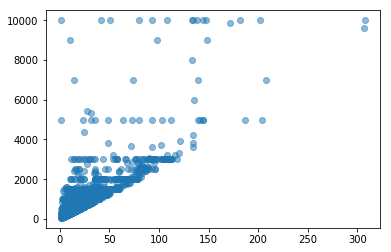

In [26]:
import matplotlib.pyplot as plt
montant = echan1.select("LOAN_AMOUNT").collect()
nb_preteurs = echan1.select("NUM_LENDERS_TOTAL").collect()
plt.scatter(nb_preteurs,montant,alpha = 0.5)
plt.show()

Commentaire : Par rapport à ce graphique, nous pouvons déduire que le montant du prêt semble n'est pas être lié de façon linéaire au nombre de preteurs. Il serait judicieux de prendre en compte d'autres variables.

# 3 – Modélisation du montant du prêt accordé 

3.1 - Pour constituer le jeu de données servant à la modélisation, enlever les colonnes "LOAN_ID" et "LENDERS" du DataFrame ‘pret_joint’. 

In [27]:
pret_joint = pret_joint.select('LOAN_AMOUNT', 'STATUS', 'SECTOR_NAME', 'COUNTRY_CODE',  'LENDER_TERM', 'NUM_LENDERS_TOTAL', 'BORROWER_GENDERS', 'DISTRIBUTION_MODEL')
pret_joint.columns
pret_joint.printSchema() # Vérification du retrait des variables 

root
 |-- LOAN_AMOUNT: double (nullable = true)
 |-- STATUS: string (nullable = true)
 |-- SECTOR_NAME: string (nullable = true)
 |-- COUNTRY_CODE: string (nullable = true)
 |-- LENDER_TERM: integer (nullable = true)
 |-- NUM_LENDERS_TOTAL: integer (nullable = true)
 |-- BORROWER_GENDERS: string (nullable = true)
 |-- DISTRIBUTION_MODEL: string (nullable = true)



3.2 – Transformer les variables de type "chaîne de caractères" en variables catégorielles afin de pouvoir réaliser la modélisation. Transformer ensuite les variables catégorielles tout juste crées en variables binaires. 

In [28]:
#  Il a été difficile pour moi de le faire.  
col_a_indexer = ["STATUS", "SECTOR_NAME", "COUNTRY_CODE", "BORROWER_GENDERS","DISTRIBUTION_MODEL"]

from pyspark.ml.feature import StringIndexer , OneHotEncoderEstimator

#indexer = StringIndexer (inputCol=col_a_indexer , outputCol=col_indexer).fit(pret_joint)
#indexed = indexer.transform(pret_joint)

In [29]:
#encoder = OneHotEncoderEstimator(inputCols=col_a_indexer+"_inx", outputCols=col_a_indexer+"_bin")
#encoded = encoder.fit(pret_joint).transform(pret_joint)
#encoded.show()

3.3 – Après ces transformations, le jeu de données est prêt pour la modélisation. Diviser ce DataFrame en deux échantillons: 70% pour l'apprentissage du modèle, 30% pour le test du modèle. 

In [35]:
# Importation de la base déjà traité sous format parquet
from pyspark.sql import SQLContext
sc = SparkContext.getOrCreate()

sqlContext = SQLContext(sc)
fichiermod = dossier + "pret_traite.parquet"
donnees = sqlContext.read.parquet(fichiermod)

# Colonnes de la nouvelles base pour la modelisation importé
data_reg = donnees.select("LENDER_TERM","NUM_LENDERS_TOTAL","LOAN_AMOUNT")
print("    Schema de la nouvelle base importée")
donnees.printSchema()


    Schema de la nouvelle base importée
root
 |-- LOAN_AMOUNT: double (nullable = true)
 |-- STATUSidxBin: vector (nullable = true)
 |-- SECTOR_NAMEidxBin: vector (nullable = true)
 |-- COUNTRY_CODEidxBin: vector (nullable = true)
 |-- LENDER_TERM: integer (nullable = true)
 |-- NUM_LENDERS_TOTAL: integer (nullable = true)
 |-- BORROWER_GENDERSidxBin: vector (nullable = true)
 |-- DISTRIBUTION_MODELidxBin: vector (nullable = true)



In [36]:
ac = pret_joint.count()     # Nombre de ligne de l'ancienne base 
nv = donnees.count()       # Nombre de ligne de la nouvelle base importée pour la modélisation 
print(" L'ancienne base 'pret_joint' avait : ",ac,"lignes\n")
print(" La nouvelle base importée a  : ",nv,"lignes")

 L'ancienne base 'pret_joint' avait :  211271 lignes

 La nouvelle base importée a  :  211271 lignes


In [37]:
# Creation des echantillons d'apprentissage et de test
splits = data_reg.randomSplit([0.7,0.3], seed=489)
train = splits[0]
test = splits[1]

train_row = train.count()
test_row = test.count()

print("ligne train :", train_row," - ligne test :",test_row)

ligne train : 147833  - ligne test : 63438


3.4 – (Question pour code en Python uniquement) Importer les fonctions de régression linéaire et d’assemblage de vecteurs nécessaires pour la modélisation. Préparer le DataFrame pour en faire un jeu d'apprentissage, en choisissant les bonnes variables en entrée et celle en sortie. 
Indication: sous Python, on pourra utiliser la fonction "VectorAssembler" 

In [38]:
#  Importation des fonctions de régression linéaire et d’assemblage de vecteurs nécessaires pour la modélisation. 
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler

# Préparation du DataFrame pour en faire un jeu d'apprentissage
assembler = VectorAssembler(inputCols = [ "LENDER_TERM","NUM_LENDERS_TOTAL"], outputCol="features")
training = assembler.transform(train).select(col("features"),(col("LOAN_AMOUNT").alias("label")))
training.show(5)

+----------+------+
|  features| label|
+----------+------+
|[1.0,11.0]| 200.0|
| [2.0,2.0]|1000.0|
| [2.0,3.0]| 800.0|
| [2.0,5.0]| 600.0|
| [2.0,7.0]| 225.0|
+----------+------+
only showing top 5 rows



3.5 – Entraîner le modèle de régression linéaire sur le jeu d’apprentissage (modèle de référence). 

In [39]:
# Entraînement du modèle de régression linéaire sur le jeu d’apprentissage
lr = LinearRegression(labelCol="label",featuresCol="features", maxIter=10,regParam=0.3)
model = lr.fit(training)
print( "Modèle de regression linéaire a été entrainé")

Modèle de regression linéaire a été entrainé


3.6 - Préparer les données de test et tester la performance du modèle de régression linéaire sur le jeu de test. Comparer les valeurs prédites et les valeurs réelles à l’aide d’une requête Spark SQL sur le DataFrame créé contenant les prédictions. 

In [40]:
# Préparation des données de test
testing = assembler.transform(test).select(col("features"),(col("LOAN_AMOUNT").alias("vraiLabel")))
testing.show(5)

+---------+---------+
| features|vraiLabel|
+---------+---------+
|[2.0,5.0]|    600.0|
|[2.0,8.0]|    250.0|
|[3.0,1.0]|     25.0|
|[3.0,1.0]|    100.0|
|[3.0,2.0]|    200.0|
+---------+---------+
only showing top 5 rows



In [41]:
# test du modele
predictions = model.transform(testing)
predicted = predictions.select("features","prediction","vraiLabel")

In [42]:
#  Comparaison des valeurs prédites et les valeurs réelles 
predicted.createOrReplaceTempView("regressionPredictions")

predicted_df =spark.sql("SELECT vraiLabel, prediction \
                           FROM regressionpredictions")
predicted_df.show()

+---------+-------------------+
|vraiLabel|         prediction|
+---------+-------------------+
|    600.0|  42.93868462104908|
|    250.0| 139.00434534913947|
|     25.0| -65.06928316469296|
|    100.0| -65.06928316469296|
|    200.0|  -33.0473962553295|
|   1000.0| 63.018264472760876|
|    400.0|  95.04015138212432|
|    250.0|  191.1058121102147|
|    300.0| 287.17147283830514|
|   1000.0|  575.3684550225762|
|   2500.0|  735.4778895693935|
|   2500.0|   3105.09752086229|
|     50.0| -44.98970331298119|
|    200.0| -44.98970331298119|
|    200.0| -44.98970331298119|
|    250.0| -44.98970331298119|
|     50.0|-12.967816403617718|
|    875.0|-12.967816403617718|
|    100.0| 19.054070505745727|
|    100.0| 19.054070505745727|
+---------+-------------------+
only showing top 20 rows



3.7 – Visualiser par un nuage de points les valeurs prédites en fonction des valeurs initiales du prêt (‘LOAN_AMOUNT’). 

In [43]:
import matplotlib.pyplot as plt
delaiVrai = predicted_df.select("vraiLabel").collect()
delaiPredit = predicted_df.select("prediction").collect()

Valeurs prédites en fonction des valeurs initiales du prêt (‘LOAN_AMOUNT’)


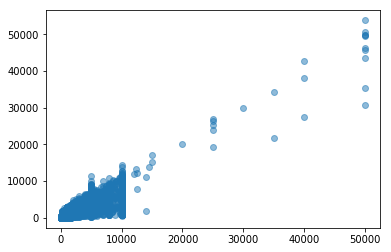

In [44]:
plt.scatter(delaiVrai, delaiPredit, alpha = 0.5)
print("Valeurs prédites en fonction des valeurs initiales du prêt (‘LOAN_AMOUNT’)")
plt.show()

3.8 – Calculer les erreurs de prédiction (RMSE et MAE). 

In [45]:
# Importation de la librairie
from pyspark.ml.evaluation import RegressionEvaluator

# Calcul des valeurs de RMSE et MAE
evaluator_rmse = RegressionEvaluator(labelCol ="vraiLabel", predictionCol="prediction", metricName="rmse")
rmse = evaluator_rmse.evaluate(predictions)

evaluator_mae = RegressionEvaluator(labelCol ="vraiLabel", predictionCol="prediction",  metricName="mae")
mae = evaluator_mae.evaluate(predictions)
print("Racine de l'erreur Quadratique Moyenne :", rmse, "\nMoyenne de l'ErreurAbsolue : ",mae)

Racine de l'erreur Quadratique Moyenne : 697.625205752271 
Moyenne de l'ErreurAbsolue :  338.56573428433876


3.9 – Entraîner des modèles de régression à base de forêt aléatoire (random forest) et arbres boostés (gradient boosted trees) sur le même jeu d’apprentissage que la régression linéaire précédente. Quels hyperparamètres avez-vous choisi pour ces 2 algorithmes ? 

# Forêt aléatoire (random forest) 

In [46]:
#Importation de la librairie
from pyspark.ml.regression import RandomForestRegressor

# Modelisation sur le jeu d'apprentissage
rfr = RandomForestRegressor(labelCol="label",featuresCol="features", numTrees =10, maxDepth =5)
model_rfr = rfr.fit(training)
print( "Modèle de Forêt aléatoire entrainé" )

Modèle de Forêt aléatoire entrainé


In [47]:
# prediction sur l'echantillon test.
predictions = model_rfr.transform(testing)

In [48]:
# Comparaison des vrai valeurs et celles prédictes sur l'echantillon test.
predictions.select("Vrailabel","prediction").show(10)

+---------+------------------+
|Vrailabel|        prediction|
+---------+------------------+
|    600.0|511.01529167076296|
|    250.0|511.01529167076296|
|     25.0|511.01529167076296|
|    100.0|511.01529167076296|
|    200.0|511.01529167076296|
|   1000.0|511.01529167076296|
|    400.0|511.01529167076296|
|    250.0|511.01529167076296|
|    300.0| 520.4291127024061|
|   1000.0| 759.8448792763451|
+---------+------------------+
only showing top 10 rows



In [49]:
# Calcul des valeurs de RMSE et MAE
evaluator_rmse = RegressionEvaluator(labelCol ="vraiLabel", predictionCol="prediction", metricName="rmse")
rmse_rfr = evaluator_rmse.evaluate(predictions)

evaluator_mae = RegressionEvaluator(labelCol ="vraiLabel", predictionCol="prediction",  metricName="mae")
mae_rfr = evaluator_mae.evaluate(predictions)


In [50]:
print("Racine de l'erreur Quadratique Moyenne :", rmse_rfr, "\nMoyenne de l'ErreurAbsolue : ",mae_rfr)

Racine de l'erreur Quadratique Moyenne : 935.392113118224 
Moyenne de l'ErreurAbsolue :  328.7980201995375


# Arbres boostés (gradient boosted trees)

In [51]:
#Importation de la librairie
from pyspark.ml.regression import GBTRegressor
# Modelisation sur le jeu d'apprentissage
gbtr = GBTRegressor(labelCol="label",featuresCol="features", maxIter = 50, maxDepth = 5)
model_gbtr = gbtr.fit(training)
print( "Modèle d'arbres boostés entrainé" )

Modèle d'arbres boostés entrainé


In [52]:
# prediction sur l'echantillon test.
predictions1 = model_gbtr.transform(testing)

# Comparaison des vrai valeurs et celles prédictes sur l'echantillon test.
predictions1.select( "Vrailabel", "prediction").show(10)

+---------+------------------+
|Vrailabel|        prediction|
+---------+------------------+
|    600.0|392.80063006945824|
|    250.0|427.03823375821565|
|     25.0| 401.4597367596844|
|    100.0| 401.4597367596844|
|    200.0| 401.4597367596844|
|   1000.0|392.80063006945824|
|    400.0|392.80063006945824|
|    250.0| 505.0124928090802|
|    300.0| 547.1563766780389|
|   1000.0| 829.4172751085944|
+---------+------------------+
only showing top 10 rows



In [53]:
# Calcul des valeurs de RMSE et MAE pour le Modèle d'arbres boostés 
evaluator_rmsegb = RegressionEvaluator(labelCol ="vraiLabel", predictionCol="prediction", metricName="rmse")
rmse_gbtr = evaluator_rmsegb.evaluate(predictions1)

evaluator_maegb = RegressionEvaluator(labelCol ="vraiLabel", predictionCol="prediction",  metricName="mae")
mae_gbtr = evaluator_maegb.evaluate(predictions1)
print("Racine de l'erreur Quadratique Moyenne :", rmse_gbtr, "\nMoyenne de l'ErreurAbsolue : ",mae_gbtr)

Racine de l'erreur Quadratique Moyenne : 881.4659228912276 
Moyenne de l'ErreurAbsolue :  294.8062092721369


 Quels hyperparamètres avez-vous choisi pour ces 2 algorithmes ?

In [54]:
# Forêt aléatoire : Le nombre d'arbre dans la foret et la profonder maximale de chaque arbre
# Arbres boostés : Nombre d'itération et la profonder maximale de chaque arbre

In [55]:
print("        ***********************************************************************")
print("        ***********  Comparaison des erreurs des différents models  ***********")
print("        ***********************************************************************\n")
print("                               RMSE                            MAE  \n")
print(" - Regression logistique : ",rmse,"          ",mae,"\n")
print(" - Random Forest         : ", rmse_rfr,"          ",mae_rfr,"\n")
print(" - Gradient-Boosted Tree : ", rmse_gbtr,"          ",mae_gbtr,"\n")

        ***********************************************************************
        ***********  Comparaison des erreurs des différents models  ***********
        ***********************************************************************

                               RMSE                            MAE  

 - Regression logistique :  697.625205752271            338.56573428433876 

 - Random Forest         :  935.392113118224            328.7980201995375 

 - Gradient-Boosted Tree :  881.4659228912276            294.8062092721369 



In [56]:
# Comment la performance se situe-t-elle par rapport au modèle de référence (régression linéaire vue en 3.5)

Par rapport au modèle de référence (régression linéaire vue en 3.5),
il est donné de constater que : du RMSE et du MAE. 

- La performance du RMSE des deux modèles sont supérieurs à celui du modèle de reference.
- La performance du MAE est meilleure avec le Gradient-Boosted Tree par rapport à celle du modèle de reference.

3.10 – Nous allons maintenant tester un modèle de classification binaire prédisant la probabilité pour un prêt d’être au-dessus de la médiane des prêts accordés. Pour cela, créer une variable binaire ‘pretMedian’ dans le DataFrame utilisé pour la régression linéaire qui a pour valeur « 1 » lorsque le montant du prêt (‘LOAN_AMOUNT’) est supérieur à la valeur médiane des prêts accordés, et a pour valeur « 0 » lorsque le montant du prêt est inférieur à la valeur médiane. Cette nouvelle variable ‘pretMedian’ sera la variable binaire à prédire par la suite. 

In [57]:
# Calcul de la mediane
mediane_loan = donnees.approxQuantile('LOAN_AMOUNT', [0.5], 0)[0]
print("La médiane = ",mediane_loan )

La médiane =  850.0


In [58]:
# preparation des données
data_cla = donnees.select("STATUSidxBin","SECTOR_NAMEidxBin","COUNTRY_CODEidxBin", "LENDER_TERM","NUM_LENDERS_TOTAL","BORROWER_GENDERSidxBin",
"DISTRIBUTION_MODELidxBin",((col("LOAN_AMOUNT")>mediane_loan).cast("Int").alias("pretMedian")))
#data_cla.show(5)


3.11 - Après ces transformations, le jeu de données est prêt pour la modélisation. Diviser ce DataFrame en deux échantillons: 70% pour l'apprentissage du modèle, 30% pour le test du modèle.

In [59]:
# séparation du jeu de données
splits =data_cla.randomSplit([0.7,0.3], seed=489)
train = splits[0] 
test = splits[1]
train_row =train.count()
test_row = test.count()
print("Ligne apprentissage :",train_row,"-Lignes test",test_row)

Ligne apprentissage : 147833 -Lignes test 63438


3.12 - (Question pour code en Python uniquement) Importer les fonctions de classification et d’assemblage de vecteurs nécessaires pour la modélisation. Préparer le DataFrame pour en faire un jeu d'apprentissage, en choisissant les bonnes variables en entrée et celle en sortie. 

In [60]:
#  Importation des fonctions de classification et d’assemblage de vecteurs nécessaires pour la modélisation. 
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler

In [61]:
# preparation jeu d'apprentissage
assembler = VectorAssembler(inputCols= ["STATUSidxBin","SECTOR_NAMEidxBin","COUNTRY_CODEidxBin", "LENDER_TERM","NUM_LENDERS_TOTAL","BORROWER_GENDERSidxBin",
"DISTRIBUTION_MODELidxBin"], outputCol="features")
training = assembler.transform(train).select(col("features"),col("pretMedian").alias("label"))
training.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|(88,[19,84,85,87]...|    1|
|(88,[19,84,85,87]...|    1|
|(88,[22,84,85,87]...|    1|
|(88,[23,84,85,87]...|    1|
|(88,[23,84,85,87]...|    1|
+--------------------+-----+
only showing top 5 rows



3.13 – Entraîner le modèle de régression logistique (classification binaire) sur le jeu d’apprentissage (modèle de référence). 

In [62]:
# entrainement du model de régression logistique
logit = LogisticRegression(labelCol="label", featuresCol="features", regParam=0.3, maxIter= 10)
model = logit.fit(training)
print("Modèle de regression logistique entrainé")

Modèle de regression logistique entrainé


3.14 - Préparer les données de test et tester la performance du modèle de régression logistique sur le jeu de test. Comparer les valeurs prédites et les valeurs réelles à l’aide d’une requête Spark SQL sur le la DataFrame créé contenant les prédictions. 

In [63]:
# preparation de l'echantillon test 
testing = assembler.transform(test).select(col("features"), (col("pretMedian")).alias("vraiLabel"))
testing.show(5)

+--------------------+---------+
|            features|vraiLabel|
+--------------------+---------+
|(88,[23,84,85,87]...|        1|
|(88,[23,84,85,86,...|        1|
|(88,[23,84,85,86]...|        1|
|(88,[23,84,85,86,...|        1|
|(88,[1,15,84,85,8...|        1|
+--------------------+---------+
only showing top 5 rows



In [64]:
# test du modele
prediction = model.transform(testing)
predicted= prediction.select("features","prediction","probability","vraiLabel")

In [65]:
# Comparaison des vrais valeurs avec celles predictes
prediction.select("rawPrediction","probability","prediction","vraiLabel").show(25,truncate = False)

+------------------------------------------+----------------------------------------+----------+---------+
|rawPrediction                             |probability                             |prediction|vraiLabel|
+------------------------------------------+----------------------------------------+----------+---------+
|[-1.0512579287593458,1.0512579287593458]  |[0.2589836171403758,0.7410163828596241] |1.0       |1        |
|[-1.4009438808698638,1.4009438808698638]  |[0.19766637452225405,0.802333625477746] |1.0       |1        |
|[-2.4126854287974875,2.4126854287974875]  |[0.08221046993739968,0.9177895300626003]|1.0       |1        |
|[-1.827731291704061,1.827731291704061]    |[0.1385087627655044,0.8614912372344956] |1.0       |1        |
|[0.3952882919345597,-0.3952882919345597]  |[0.5975550970866053,0.40244490291339474]|0.0       |1        |
|[0.39728007237422663,-0.39728007237422663]|[0.5980339932162858,0.4019660067837142] |0.0       |1        |
|[0.32967675595769663,-0.329676755957

3.15 – Calculer la matrice de confusion obtenue sur le jeu de test, ainsi que les métriques habituellement utilisées pour évaluer la performance d’un modèle de classification binaire : TP, FP, TN, FN, accuracy, precision, recall. 

In [66]:
print("Matrice de confusion et métriques habituelles")
tp = float(predicted.filter("prediction == 1 AND vrailabel == 1").count())
fp = float(predicted.filter("prediction == 1 AND vrailabel == 0").count())
tn = float(predicted.filter("prediction == 0 AND vrailabel == 0").count())
fn = float(predicted.filter("prediction == 0 AND vrailabel == 1").count())
metrics = spark.createDataFrame([("TP", tp),("FP", fp),("TN", tn),("FN", fn),
("Accuracy", (tp + tn)/(tp +fp +tn +fn)),
("Precision", tp/(tp+fp)),
("Recall",tp/(tp + fn))], ["metric", "value_logit"])
metrics.show()

Matrice de confusion et métriques habituelles
+---------+------------------+
|   metric|       value_logit|
+---------+------------------+
|       TP|           22339.0|
|       FP|            4139.0|
|       TN|           27929.0|
|       FN|            9031.0|
| Accuracy|0.7923957249598033|
|Precision|0.8436815469446333|
|   Recall| 0.712113484220593|
+---------+------------------+



3.16 – Evaluer la performance synthétique du modèle de régression logistique à travers l’AUC (surface sous la courbe ROC). 

In [67]:
# Qualité de la prediction
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(labelCol="vraiLabel",rawPredictionCol="rawPrediction", 
metricName="areaUnderROC")

aucLogit = evaluator_auc.evaluate(prediction)
print("AUC = ", aucLogit)

AUC =  0.8891635066088609


In [68]:
# ajout de l'AUC dans le tableau des metriques usuelle du logit
newrow = spark.createDataFrame([("AUC",aucLogit)],["metric", "value_logit"])
metrics =metrics.union(newrow)
metrics.show()

+---------+------------------+
|   metric|       value_logit|
+---------+------------------+
|       TP|           22339.0|
|       FP|            4139.0|
|       TN|           27929.0|
|       FN|            9031.0|
| Accuracy|0.7923957249598033|
|Precision|0.8436815469446333|
|   Recall| 0.712113484220593|
|      AUC|0.8891635066088609|
+---------+------------------+



3.17 – Entraîner, sur le même jeu d’apprentissage que celui utilisé sur la régression logistique précédente (i.e. créé en 3.11), 4 autres modèles de classification binaire: classifieur naïf de Bayes (Naive Bayes), machines à vecteurs supports linéaires (linear SVM), forêts aléatoires (random forest) et arbres boostés (gradient boosted trees). Quels hyperparamètres avez-vous choisi pour ces 4 algorithmes de classification? 

# Classifieur naïf de Bayes (Naive Bayes)

In [69]:
from pyspark.ml.classification import NaiveBayes

In [70]:
# create the trainer and set its parameters
#nb = NaiveBayes(labelCol="label",featuresCol="features", smoothing=1.0, modelType="bernoulli" )
nb = NaiveBayes(smoothing=1.0 )
modelNB  = nb.fit(training)

In [71]:
# Comparaison sur l'echantillon test.
predictions = modelNB.transform(testing)
predictions.select("probability", "prediction","vraiLabel").show(10)

+--------------------+----------+---------+
|         probability|prediction|vraiLabel|
+--------------------+----------+---------+
|[0.05459922322525...|       1.0|        1|
|[1.18104038275823...|       1.0|        1|
|[6.46043224200738...|       1.0|        1|
|[0.00161515768475...|       1.0|        1|
|[0.86122263019358...|       0.0|        1|
|[0.96104050030400...|       0.0|        1|
|[0.75288163710982...|       0.0|        0|
|[0.99642864492842...|       0.0|        0|
|[0.99642864492842...|       0.0|        0|
|[0.99285435805441...|       0.0|        0|
+--------------------+----------+---------+
only showing top 10 rows



In [72]:
predicted= predictions.select("features","prediction","probability","vraiLabel")

In [73]:
evaluator_auc = BinaryClassificationEvaluator(labelCol="vraiLabel",rawPredictionCol="rawPrediction", metricName="areaUnderROC")
aucNB= evaluator_auc.evaluate(predictions)

In [74]:
print("Matrice de confusion, AUC  et métriques habituelles")
print("          Naives Bayes      ")
tp = float(predicted.filter("prediction == 1 AND vrailabel == 1").count())
fp = float(predicted.filter("prediction == 1 AND vrailabel == 0").count())
tn = float(predicted.filter("prediction == 0 AND vrailabel == 0").count())
fn = float(predicted.filter("prediction == 0 AND vrailabel == 1").count())
metricsNB = spark.createDataFrame([("TP", tp),("FP", fp),("TN", tn),("FN", fn),("AUC",aucNB),
("Accuracy", (tp + tn)/(tp +fp +tn +fn)),
("Precision", tp/(tp+fp)),
("Recall",tp/(tp + fn))], ["metric", "value_Naives_Bayes"])
metricsNB.show()

Matrice de confusion, AUC  et métriques habituelles
          Naives Bayes      
+---------+-------------------+
|   metric| value_Naives_Bayes|
+---------+-------------------+
|       TP|            23425.0|
|       FP|             4234.0|
|       TN|            27834.0|
|       FN|             7945.0|
|      AUC|0.15171191794023645|
| Accuracy| 0.8080172767111196|
|Precision| 0.8469214360605951|
|   Recall| 0.7467325470194454|
+---------+-------------------+



# Machines à vecteurs supports linéaires (linear SVM)

In [75]:
from pyspark.ml.classification import  LinearSVC

In [76]:
linearsvc =  LinearSVC(maxIter = 10, regParam = 0.3)
Modelsvm = linearsvc.fit(training)
#modelsvm = svm.fit(training)

In [77]:
predictions = Modelsvm .transform(testing)
predictions.select('vraiLabel','prediction').show()

+---------+----------+
|vraiLabel|prediction|
+---------+----------+
|        1|       1.0|
|        1|       1.0|
|        1|       1.0|
|        1|       1.0|
|        1|       0.0|
|        1|       0.0|
|        0|       0.0|
|        0|       0.0|
|        0|       0.0|
|        0|       0.0|
|        1|       0.0|
|        0|       0.0|
|        0|       0.0|
|        1|       0.0|
|        0|       0.0|
|        0|       0.0|
|        1|       0.0|
|        1|       0.0|
|        1|       0.0|
|        1|       0.0|
+---------+----------+
only showing top 20 rows



In [78]:
evaluator_auc = BinaryClassificationEvaluator(labelCol="vraiLabel",rawPredictionCol="rawPrediction", 
metricName="areaUnderROC")
aucSVM= evaluator_auc.evaluate(predictions)
predicted= predictions.select("prediction","vraiLabel")

In [79]:
print("Matrice de confusion, AUC  et métriques habituelles")
print("          linear SVM      ")
tp = float(predicted.filter("prediction == 1 AND vrailabel == 1").count())
fp = float(predicted.filter("prediction == 1 AND vrailabel == 0").count())
tn = float(predicted.filter("prediction == 0 AND vrailabel == 0").count())
fn = float(predicted.filter("prediction == 0 AND vrailabel == 1").count())
metricssvm = spark.createDataFrame([("TP", tp),("FP", fp),("TN", tn),("FN", fn),("AUC",aucSVM),
("Accuracy", (tp + tn)/(tp +fp +tn +fn)),
("Precision", tp/(tp+fp)),
("Recall",tp/(tp + fn))], ["metric", "value_linear_SVM"])
metricssvm.show()

Matrice de confusion, AUC  et métriques habituelles
          linear SVM      
+---------+------------------+
|   metric|  value_linear_SVM|
+---------+------------------+
|       TP|           19520.0|
|       FP|            3018.0|
|       TN|           29050.0|
|       FN|           11850.0|
|      AUC|0.8879427548544137|
| Accuracy|0.7656294334625934|
|Precision|0.8660928210133996|
|   Recall|0.6222505578578259|
+---------+------------------+



# Forêts aléatoires (random forest)

In [81]:
from pyspark.ml.classification import RandomForestClassifier
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50, maxDepth=5)
modelrf = rf.fit(training)

In [82]:
predictions = modelrf .transform(testing)
predictions.select('vraiLabel','prediction','probability').show(10)

predicted= predictions.select("features","prediction","probability","vraiLabel")
evaluator_auc = BinaryClassificationEvaluator(labelCol="vraiLabel",rawPredictionCol="rawPrediction", 
metricName="areaUnderROC")
aucRF= evaluator_auc.evaluate(predictions)

+---------+----------+--------------------+
|vraiLabel|prediction|         probability|
+---------+----------+--------------------+
|        1|       1.0|[0.28055464149594...|
|        1|       1.0|[0.10222184947804...|
|        1|       1.0|[0.07994214147897...|
|        1|       1.0|[0.10192231577270...|
|        1|       0.0|[0.58667096932638...|
|        1|       0.0|[0.59703388977251...|
|        0|       0.0|[0.57938405244872...|
|        0|       0.0|[0.59703388977251...|
|        0|       0.0|[0.59703388977251...|
|        0|       0.0|[0.59703388977251...|
+---------+----------+--------------------+
only showing top 10 rows



In [83]:
predicted= predictions.select("features","prediction","probability","vraiLabel")

In [84]:
evaluator_auc = BinaryClassificationEvaluator(labelCol="vraiLabel",rawPredictionCol="rawPrediction", 
metricName="areaUnderROC")
aucRF= evaluator_auc.evaluate(predictions)

In [85]:
print("Matrice de confusion, AUC  et métriques habituelles")
print("          forêt aléatoire      ")
tp = float(predicted.filter("prediction == 1 AND vrailabel == 1").count())
fp = float(predicted.filter("prediction == 1 AND vrailabel == 0").count())
tn = float(predicted.filter("prediction == 0 AND vrailabel == 0").count())
fn = float(predicted.filter("prediction == 0 AND vrailabel == 1").count())
metricsrf = spark.createDataFrame([("TP", tp),("FP", fp),("TN", tn),("FN", fn),("AUC",aucRF),
("Accuracy", (tp + tn)/(tp +fp +tn +fn)),
("Precision", tp/(tp+fp)),
("Recall",tp/(tp + fn))], ["metric", "value_random_forest"])
metricsrf.show()

Matrice de confusion, AUC  et métriques habituelles
          forêt aléatoire      
+---------+-------------------+
|   metric|value_random_forest|
+---------+-------------------+
|       TP|            25584.0|
|       FP|             1976.0|
|       TN|            30092.0|
|       FN|             5786.0|
|      AUC| 0.9403487146714734|
| Accuracy| 0.8776443141334846|
|Precision| 0.9283018867924528|
|   Recall| 0.8155562639464456|
+---------+-------------------+



In [86]:
print("Matrice de confusion, AUC  et métriques habituelles")
print("          forêt aléatoire      ")
tp = float(predicted.filter("prediction == 1 AND vrailabel == 1").count())
fp = float(predicted.filter("prediction == 1 AND vrailabel == 0").count())
tn = float(predicted.filter("prediction == 0 AND vrailabel == 0").count())
fn = float(predicted.filter("prediction == 0 AND vrailabel == 1").count())
metricsrf = spark.createDataFrame([("TP", tp),("FP", fp),("TN", tn),("FN", fn),("AUC",aucRF),
("Accuracy", (tp + tn)/(tp +fp +tn +fn)),
("Precision", tp/(tp+fp)),
("Recall",tp/(tp + fn))], ["metric", "value_random_forest"])
metricsrf.show()

Matrice de confusion, AUC  et métriques habituelles
          forêt aléatoire      
+---------+-------------------+
|   metric|value_random_forest|
+---------+-------------------+
|       TP|            25584.0|
|       FP|             1976.0|
|       TN|            30092.0|
|       FN|             5786.0|
|      AUC| 0.9403487146714734|
| Accuracy| 0.8776443141334846|
|Precision| 0.9283018867924528|
|   Recall| 0.8155562639464456|
+---------+-------------------+



# Arbres boostés (gradient boosted trees)

In [87]:
from pyspark.ml.classification import GBTClassifier
gbt = GBTClassifier(maxIter = 50, maxDepth = 5)
modelgbt = gbt.fit(training)
predictions = modelgbt.transform(testing)

In [88]:
predictions.select('vraiLabel','prediction','probability').show(10)

+---------+----------+--------------------+
|vraiLabel|prediction|         probability|
+---------+----------+--------------------+
|        1|       1.0|[0.03133496360468...|
|        1|       1.0|[0.02150886370035...|
|        1|       1.0|[0.02150914581715...|
|        1|       1.0|[0.02150886370035...|
|        1|       0.0|[0.62154839584130...|
|        1|       0.0|[0.68737380927127...|
|        0|       0.0|[0.58147439377924...|
|        0|       0.0|[0.73746739844807...|
|        0|       0.0|[0.73746739844807...|
|        0|       0.0|[0.73746739844807...|
+---------+----------+--------------------+
only showing top 10 rows



In [89]:
evaluator_auc = BinaryClassificationEvaluator(labelCol="vraiLabel",rawPredictionCol="rawPrediction", 
metricName="areaUnderROC")
aucgbt= evaluator_auc.evaluate(predictions)

In [90]:
predicted= predictions.select("features","prediction","probability","vraiLabel")

In [91]:
print("Matrice de confusion, AUC  et métriques habituelles")
print("         Arbre boostés      ")
tp = float(predicted.filter("prediction == 1 AND vrailabel == 1").count())
fp = float(predicted.filter("prediction == 1 AND vrailabel == 0").count())
tn = float(predicted.filter("prediction == 0 AND vrailabel == 0").count())
fn = float(predicted.filter("prediction == 0 AND vrailabel == 1").count())
metricsgbt = spark.createDataFrame([("TP", tp),("FP", fp),("TN", tn),("FN", fn),("AUC",aucgbt),
("Accuracy", (tp + tn)/(tp +fp +tn +fn)),
("Precision", tp/(tp+fp)),
("Recall",tp/(tp + fn))], ["metric", "value_Arbre_boosté"])
metricsgbt.show()

Matrice de confusion, AUC  et métriques habituelles
         Arbre boostés      
+---------+------------------+
|   metric|value_Arbre_boosté|
+---------+------------------+
|       TP|           27124.0|
|       FP|            2589.0|
|       TN|           29479.0|
|       FN|            4246.0|
|      AUC|0.9623459367444753|
| Accuracy|0.8922570068413254|
|Precision|0.9128664221048026|
|   Recall|0.8646477526299012|
+---------+------------------+



In [92]:
#  Quels hyperparamètres avez-vous choisi pour ces 4 algorithmes de classification?

# foret aléatoires :numTrees=200, maxDepth=20
# Arbres boostés : maxIter = 50, maxDepth = 5

 Comment la performance se situe-t-elle par rapport au modèle de classification binaire de référence ?

In [93]:
 # Jointure des métriques des différents modèles
synt1 = metrics.join(metricsNB,"metric")
synt2 = synt1.join(metricssvm,"metric")
synt3 = synt2.join(metricsrf,"metric")
synt4 = synt3.join(metricsgbt,"metric")

synthèse = synt4.filter((synt4.metric == "Recall") | (synt4.metric == "Accuracy")| (synt4.metric == "Precision")| (synt4.metric == "AUC"))


In [94]:
print("                   Tableau récapitulatif des métriques pour chaque modèle\n")
synthèse.show()

                   Tableau récapitulatif des métriques pour chaque modèle

+---------+------------------+-------------------+------------------+-------------------+------------------+
|   metric|       value_logit| value_Naives_Bayes|  value_linear_SVM|value_random_forest|value_Arbre_boosté|
+---------+------------------+-------------------+------------------+-------------------+------------------+
|   Recall| 0.712113484220593| 0.7467325470194454|0.6222505578578259| 0.8155562639464456|0.8646477526299012|
| Accuracy|0.7923957249598033| 0.8080172767111196|0.7656294334625934| 0.8776443141334846|0.8922570068413254|
|Precision|0.8436815469446333| 0.8469214360605951|0.8660928210133996| 0.9283018867924528|0.9128664221048026|
|      AUC|0.8891635066088609|0.15171191794023645|0.8879427548544137| 0.9403487146714734|0.9623459367444753|
+---------+------------------+-------------------+------------------+-------------------+------------------+



                                        Commentaires
*** Recall & Accuracy
Relativement à ces deux metriques, seul le modèle linéaire SVM a une performence en 
dessous du modèle de référence. l'arbre boosté enregiste la meilleure performance 
pour ces deux dernières metriques.

*** Précision
S'agissant de la précision, tous les 04 modèles ont une performance supérieure à celle
de référence et cela est d'autant plus mportant avec la forêt aléatoire.

*** AUC
Par rapport à l'aire de la courbe ROC, le modèle Naive Bayes est celle qui enregistre la 
plus mauvaise performance 15% suivi du modèle linéaire svm qui est très légèrement en 
dessous de la reférence.

Globalement, les meilleures performance observés par rapport à la références qui est le 
modèle logit sont respectivement dans l'ordre d'importance : 

    1: Les Arbres boostés (gradient boosted trees)
    2: Les Forêts aléatoires (random forest)